# 03_XGB_FD001 — XGBoost baseline, C-MAPSS FD001

**Protocol:** `README.md` v1.0 (locked 2026-09-28) — Notebook 3 of 4 (`01_LSTM_FD001`, `02_LSTM_FD003`, `03_XGB_FD001`, `04_XGB_FD003`).
**Model:** XGBoost | **Dataset:** FD001 | **Training:** Google Colab, GPU T4 (histogram method) | **Inference-latency benchmark:** CPU only (see S16).

The data pipeline (S1–S11) is byte-for-byte identical to `01_LSTM_FD001` — S11 fingerprints
must match. Only the model (S12–S16) differs: XGBoost regression instead of LSTM.
Run top to bottom ("Restart & Run All") before saving results. Do not change hyper-parameters
after seeing S15 (test evaluation) — see README section 11 (Deviation policy).

## S1 — Environment

In [1]:
# S1 — Environment: installs, imports, version logging
import os, sys, json, time, platform, hashlib, random, subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("XGBoost     :", xgb.__version__)

try:
    import torch
    cuda_available = torch.cuda.is_available()
    gpu_name = torch.cuda.get_device_name(0) if cuda_available else None
except Exception:
    cuda_available = False
    gpu_name = None
print("CUDA avail. :", cuda_available)
if gpu_name:
    print("GPU         :", gpu_name)

try:
    cpu_model = subprocess.check_output("cat /proc/cpuinfo | grep 'model name' | uniq", shell=True).decode().strip()
except Exception:
    cpu_model = platform.processor() or "unknown"
print("CPU         :", cpu_model)


Python      : 3.13.15
NumPy       : 2.1.3
Pandas      : 2.2.3
XGBoost     : 3.4.1
CUDA avail. : True
GPU         : Tesla T4
CPU         : model name	: Intel(R) Xeon(R) CPU @ 2.00GHz


## S2 — Drive & paths

In [2]:
# S2 — Drive & paths
from google.colab import drive
drive.mount('/content/drive')

DATASET_ID = "FD001"
MODEL_NAME = "XGB"

BASE_DIR    = "/content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003"
DATA_DIR    = os.path.join(BASE_DIR, "RUL_Prediction__FD001")   # raw train/test/RUL files live here
RESULTS_DIR = os.path.join(BASE_DIR, "results", f"{MODEL_NAME}_{DATASET_ID}")
MODELS_DIR  = os.path.join(RESULTS_DIR, "models")
FIGS_DIR    = os.path.join(RESULTS_DIR, "figures")

for d in (RESULTS_DIR, MODELS_DIR, FIGS_DIR):
    os.makedirs(d, exist_ok=True)

assert os.path.isdir(DATA_DIR), f"Data folder not found: {DATA_DIR} — check the Drive folder name."
print("BASE_DIR   :", BASE_DIR)
print("DATA_DIR   :", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("Files in DATA_DIR:", sorted(os.listdir(DATA_DIR)))


Mounted at /content/drive
BASE_DIR   : /content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003
DATA_DIR   : /content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003/RUL_Prediction__FD001
RESULTS_DIR: /content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003/results/XGB_FD001
Files in DATA_DIR: ['RUL_FD001.txt', 'test_FD001.txt', 'train_FD001.txt']


## S3 — Configuration (fixed by README.md, not tuned per dataset)

In [3]:
# S3 — Configuration
CONFIG = {
    "dataset_id": DATASET_ID,
    "model": MODEL_NAME,

    # ---- data (identical to the LSTM notebooks) ----
    "sensor_cols": ["s2","s3","s4","s7","s8","s9","s11","s12","s13",
                    "s14","s15","s17","s20","s21"],
    "rul_clip": 125,
    "window_size": 30,
    "val_fraction": 0.20,
    "split_seed": 42,

    # ---- XGBoost hyper-parameters (identical for FD001 and FD003) ----
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "early_stopping_rounds": 30,

    # ---- repetitions ----
    "seeds": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],

    # ---- efficiency benchmark ----
    "latency_warmup_calls": 50,
    "latency_timed_calls": 1000,
}

# Train on GPU T4 when available (histogram method), same policy as the LSTM notebooks;
# inference-latency benchmark in S16 always runs on CPU regardless of this setting.
TRAIN_DEVICE = "cuda" if cuda_available else "cpu"
print(f"Training device: {TRAIN_DEVICE}")
print(json.dumps(CONFIG, indent=2))


Training device: cuda
{
  "dataset_id": "FD001",
  "model": "XGB",
  "sensor_cols": [
    "s2",
    "s3",
    "s4",
    "s7",
    "s8",
    "s9",
    "s11",
    "s12",
    "s13",
    "s14",
    "s15",
    "s17",
    "s20",
    "s21"
  ],
  "rul_clip": 125,
  "window_size": 30,
  "val_fraction": 0.2,
  "split_seed": 42,
  "n_estimators": 1000,
  "learning_rate": 0.05,
  "max_depth": 6,
  "subsample": 0.8,
  "colsample_bytree": 0.8,
  "min_child_weight": 1,
  "reg_lambda": 1.0,
  "tree_method": "hist",
  "early_stopping_rounds": 30,
  "seeds": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "latency_warmup_calls": 50,
  "latency_timed_calls": 1000
}


## S4 — Reproducibility helpers

In [4]:
# S4 — Reproducibility
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)

def sha256_of_array(arr: np.ndarray) -> str:
    return hashlib.sha256(np.ascontiguousarray(arr).tobytes()).hexdigest()

def sha256_of_file(path: str) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()


## S5 — Load raw data

In [5]:
# S5 — Load raw data
train_path = os.path.join(DATA_DIR, f"train_{DATASET_ID}.txt")
test_path  = os.path.join(DATA_DIR, f"test_{DATASET_ID}.txt")
rul_path   = os.path.join(DATA_DIR, f"RUL_{DATASET_ID}.txt")

for p in (train_path, test_path, rul_path):
    assert os.path.isfile(p), f"Missing file: {p}"

raw_checksums = {
    os.path.basename(train_path): sha256_of_file(train_path),
    os.path.basename(test_path):  sha256_of_file(test_path),
    os.path.basename(rul_path):   sha256_of_file(rul_path),
}
print("Raw file SHA-256 (must match data/README.md — same files as the LSTM notebook):")
for k, v in raw_checksums.items():
    print(f"  {k}: {v}")

col_names = ["unit_number", "time_in_cycles",
             "op_setting_1", "op_setting_2", "op_setting_3"] + [f"s{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test_df  = pd.read_csv(test_path,  sep=r"\s+", header=None, names=col_names)
rul_df   = pd.read_csv(rul_path,   sep=r"\s+", header=None, names=["RUL"])

n_train_engines = train_df["unit_number"].nunique()
n_test_engines  = test_df["unit_number"].nunique()
print(f"Train engines: {n_train_engines} (expected 100)")
print(f"Test engines : {n_test_engines} (expected 100)")
assert n_train_engines == 100 and n_test_engines == 100, "Unexpected engine count — check the raw files."
assert len(rul_df) == n_test_engines, "RUL file length must match number of test engines."


Raw file SHA-256 (must match data/README.md — same files as the LSTM notebook):
  train_FD001.txt: 963b5e22825b34d8b21c69e1aeb4af3e647050eb672ee8834ba4b5d91d2de0f8
  test_FD001.txt: 3cda7109ce17bafb5443f2ac926cfcf88154b941b8c4cf95eb55d1ddd6f52851
  RUL_FD001.txt: a19c8ec94931949d0485bdc35118206e9c81c4547b422efb9cf86f4ceddbceca
Train engines: 100 (expected 100)
Test engines : 100 (expected 100)


## S6 — RUL labels (piece-wise linear, clipped at 125)

In [6]:
# S6 — RUL labels
def add_train_rul(df: pd.DataFrame, clip: int) -> pd.DataFrame:
    max_cycle = df.groupby("unit_number")["time_in_cycles"].transform("max")
    df = df.copy()
    df["RUL_raw"] = max_cycle - df["time_in_cycles"]
    df["RUL"] = df["RUL_raw"].clip(upper=clip)
    return df

train_df = add_train_rul(train_df, CONFIG["rul_clip"])

test_rul_raw = rul_df["RUL"].to_numpy().astype(np.float32)
test_rul_clipped = np.clip(test_rul_raw, a_min=None, a_max=CONFIG["rul_clip"]).astype(np.float32)

print("Train RUL (clipped) stats:", train_df["RUL"].describe()[["min","mean","max"]].to_dict())
print("Test RUL (raw) stats     :", pd.Series(test_rul_raw).describe()[["min","mean","max"]].to_dict())


Train RUL (clipped) stats: {'min': 0.0, 'mean': 86.82928602588338, 'max': 125.0}
Test RUL (raw) stats     : {'min': 7.0, 'mean': 75.5199966430664, 'max': 145.0}


## S7 — Feature check (14-sensor list, per README section 4)

In [7]:
# S7 — Feature check
all_sensor_cols = [f"s{i}" for i in range(1, 22)]
dropped_sensors = [c for c in all_sensor_cols if c not in CONFIG["sensor_cols"]]
assert len(CONFIG["sensor_cols"]) == 14, "Protocol fixes 14 input sensors."

variance_table = train_df[all_sensor_cols].var().sort_values()
print("Variance of sensors dropped by the protocol (expected near-zero):")
print(variance_table[dropped_sensors])
print()
print("Variance of sensors kept by the protocol (expected non-trivial):")
print(variance_table[CONFIG["sensor_cols"]])

low_variance_but_kept = [c for c in CONFIG["sensor_cols"] if variance_table[c] < 1e-8]
if low_variance_but_kept:
    print("\nNOTE — discrepancy vs. the protocol's variance assumption, sensors kept by protocol but near-zero variance here:",
          low_variance_but_kept, "(reported as-is, feature list not changed silently — see README S7.)")


Variance of sensors dropped by the protocol (expected near-zero):
s1     4.273435e-21
s5     1.152399e-23
s6     1.929279e-06
s10    2.172333e-25
s16    2.422479e-28
s18    0.000000e+00
s19    0.000000e+00
dtype: float64

Variance of sensors kept by the protocol (expected non-trivial):
s2       0.250053
s3      37.590994
s4      81.010886
s7       0.783388
s8       0.005039
s9     487.653568
s11      0.071336
s12      0.543985
s13      0.005172
s14    363.900490
s15      0.001407
s17      2.398667
s20      0.032669
s21      0.011718
dtype: float64


## S8 — Validation split (by engine, 80/20, split_seed=42)

In [8]:
# S8 — Engine split
all_engines = np.sort(train_df["unit_number"].unique())
rng = np.random.RandomState(CONFIG["split_seed"])
perm = rng.permutation(all_engines)

n_val = int(round(len(all_engines) * CONFIG["val_fraction"]))
val_engines = np.sort(perm[:n_val])
train_engines = np.sort(perm[n_val:])

print(f"Train engines ({len(train_engines)}):", train_engines.tolist())
print(f"Val engines   ({len(val_engines)}):", val_engines.tolist())

val_engines_hash = hashlib.sha256(val_engines.tobytes()).hexdigest()
print("Validation-engine-set hash (must match 01_LSTM_FD001):", val_engines_hash)

train_split_df = train_df[train_df["unit_number"].isin(train_engines)].reset_index(drop=True)
val_split_df   = train_df[train_df["unit_number"].isin(val_engines)].reset_index(drop=True)


Train engines (80): [2, 3, 4, 6, 7, 8, 9, 10, 12, 14, 15, 16, 17, 18, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 33, 35, 36, 37, 38, 39, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 72, 73, 75, 76, 79, 80, 82, 83, 85, 86, 87, 88, 89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100]
Val engines   (20): [1, 5, 11, 13, 19, 23, 31, 32, 34, 40, 45, 46, 54, 71, 74, 77, 78, 81, 84, 91]
Validation-engine-set hash (must match 01_LSTM_FD001): e805177b4036c7b14abff995cf89af03b5a325e2c37e319463d8027b05002126


## S9 — Scaling (StandardScaler, fit on the 80 training engines only)

In [9]:
# S9 — Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_split_df[CONFIG["sensor_cols"]])

def scale_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out[CONFIG["sensor_cols"]] = scaler.transform(df[CONFIG["sensor_cols"]])
    return out

train_split_scaled = scale_df(train_split_df)
val_split_scaled   = scale_df(val_split_df)
test_scaled         = scale_df(test_df)

print("Scaler fitted on", train_split_df.shape[0], "rows from", len(train_engines), "engines.")
print("Scaled feature mean (train, should be ~0):", train_split_scaled[CONFIG["sensor_cols"]].mean().mean().round(4))


Scaler fitted on 16561 rows from 80 engines.
Scaled feature mean (train, should be ~0): -0.0


## S10 — Windowing (length 30, stride 1, never crosses engine boundaries)

In [10]:
# S10 — Windowing (same 3D arrays as the LSTM notebook — flattened only at model input, S12)
W = CONFIG["window_size"]
FEATS = CONFIG["sensor_cols"]

def make_windows(df: pd.DataFrame, window: int):
    X_list, y_list = [], []
    for _, g in df.sort_values("time_in_cycles").groupby("unit_number"):
        vals = g[FEATS].to_numpy(dtype=np.float32)
        ruls = g["RUL"].to_numpy(dtype=np.float32)
        n = len(g)
        if n < window:
            continue  # protocol: no padding (README S4 — Test input)
        for end in range(window, n + 1):
            X_list.append(vals[end - window:end])
            y_list.append(ruls[end - 1])
    return np.stack(X_list).astype(np.float32), np.array(y_list, dtype=np.float32)

def make_test_last_window(df: pd.DataFrame, window: int):
    X_list, engine_ids = [], []
    skipped = []
    for uid, g in df.sort_values("time_in_cycles").groupby("unit_number"):
        vals = g[FEATS].to_numpy(dtype=np.float32)
        if len(g) < window:
            skipped.append(uid)
            continue
        X_list.append(vals[-window:])
        engine_ids.append(uid)
    assert not skipped, f"Test engines with fewer than {window} cycles (no padding allowed): {skipped}"
    return np.stack(X_list).astype(np.float32), np.array(engine_ids)

X_train, y_train = make_windows(train_split_scaled, W)
X_val,   y_val   = make_windows(val_split_scaled, W)
X_test, test_engine_ids = make_test_last_window(test_scaled, W)

order = np.argsort(test_engine_ids)
X_test = X_test[order]
test_engine_ids = test_engine_ids[order]
y_test_clipped = test_rul_clipped[test_engine_ids - 1]
y_test_raw     = test_rul_raw[test_engine_ids - 1]

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val  :", X_val.shape,   " y_val  :", y_val.shape)
print("X_test :", X_test.shape, " y_test_clipped:", y_test_clipped.shape)


X_train: (14241, 30, 14)  y_train: (14241,)
X_val  : (3490, 30, 14)  y_val  : (3490,)
X_test : (100, 30, 14)  y_test_clipped: (100,)


## S11 — Data fingerprints (must match `01_LSTM_FD001` on the same dataset)

In [11]:
# S11 — Fingerprints
fingerprint = {
    "dataset_id": DATASET_ID,
    "X_train": sha256_of_array(X_train),
    "y_train": sha256_of_array(y_train),
    "X_val":   sha256_of_array(X_val),
    "y_val":   sha256_of_array(y_val),
    "X_test":  sha256_of_array(X_test),
    "y_test_raw":     sha256_of_array(y_test_raw),
    "y_test_clipped": sha256_of_array(y_test_clipped),
    "val_engines_hash": val_engines_hash,
}
with open(os.path.join(RESULTS_DIR, "fingerprint.json"), "w") as f:
    json.dump(fingerprint, f, indent=2)

print(json.dumps(fingerprint, indent=2))
print()
print("ACTION: open results/LSTM_FD001/fingerprint.json (the LSTM run on the same dataset)"
      " and confirm every hash above matches.")


{
  "dataset_id": "FD001",
  "X_train": "d74ed7e1d6234994a20f6d57c17e459d4e500282e2f0feecb70476ad760d7011",
  "y_train": "7270c6dfdbc8e9db536ccbf8b10b265a15227af4ef68179bbe3e03bd1f340ab6",
  "X_val": "439969f5a74e432d5adada01624a5ef35761dec91a61e6779f4ae431af03bc48",
  "y_val": "36f10ab827b20ba63aced3ca80852535f437124d43761343b7c53f227d46e4e0",
  "X_test": "03a55b78cc33e8b557b9b2883caa3bacfb73909ba62413612613c3c98bde982b",
  "y_test_raw": "1a62ce5931da995ce9e2329da45cc35b71fe3960f02407df1a2cc697931f6a93",
  "y_test_clipped": "0786bdaa54d8c0c2ac8645fbe9b473c470cdf75a10af2e89d0278bc13f932f89",
  "val_engines_hash": "e805177b4036c7b14abff995cf89af03b5a325e2c37e319463d8027b05002126"
}

ACTION: open results/LSTM_FD001/fingerprint.json (the LSTM run on the same dataset) and confirm every hash above matches.


## S12 — Model definition (XGBoost) and flattened input

In [12]:
# S12 — Model definition
# XGBoost takes tabular input: flatten each (30, 14) window to 420 features, time-major order.
def flatten_windows(X_3d: np.ndarray) -> np.ndarray:
    return X_3d.reshape(X_3d.shape[0], -1)

X_train_flat = flatten_windows(X_train)
X_val_flat   = flatten_windows(X_val)
X_test_flat  = flatten_windows(X_test)
print("Flattened shapes:", X_train_flat.shape, X_val_flat.shape, X_test_flat.shape)

def make_model(seed: int) -> xgb.XGBRegressor:
    kwargs = dict(
        objective="reg:squarederror",
        eval_metric="rmse",
        n_estimators=CONFIG["n_estimators"],
        learning_rate=CONFIG["learning_rate"],
        max_depth=CONFIG["max_depth"],
        subsample=CONFIG["subsample"],
        colsample_bytree=CONFIG["colsample_bytree"],
        min_child_weight=CONFIG["min_child_weight"],
        reg_lambda=CONFIG["reg_lambda"],
        tree_method=CONFIG["tree_method"],
        early_stopping_rounds=CONFIG["early_stopping_rounds"],
        random_state=seed,
        n_jobs=-1,
    )
    try:
        # xgboost >= 2.0: explicit training device
        return xgb.XGBRegressor(device=TRAIN_DEVICE, **kwargs)
    except TypeError:
        # older xgboost: GPU selected via tree_method variant
        if TRAIN_DEVICE == "cuda":
            kwargs["tree_method"] = "gpu_hist"
        return xgb.XGBRegressor(**kwargs)

print("XGBoost hyper-parameters (identical for FD001 and FD003):")
print(json.dumps({k: v for k, v in CONFIG.items() if k not in
                   ("sensor_cols", "seeds")}, indent=2))


Flattened shapes: (14241, 420) (3490, 420) (100, 420)
XGBoost hyper-parameters (identical for FD001 and FD003):
{
  "dataset_id": "FD001",
  "model": "XGB",
  "rul_clip": 125,
  "window_size": 30,
  "val_fraction": 0.2,
  "split_seed": 42,
  "n_estimators": 1000,
  "learning_rate": 0.05,
  "max_depth": 6,
  "subsample": 0.8,
  "colsample_bytree": 0.8,
  "min_child_weight": 1,
  "reg_lambda": 1.0,
  "tree_method": "hist",
  "early_stopping_rounds": 30,
  "latency_warmup_calls": 50,
  "latency_timed_calls": 1000
}


## S13 — Single-seed dry run (sanity check on train/val only, test set untouched)

In [13]:
# S13 — Single-seed dry run
set_seed(CONFIG["seeds"][0])
dry_model = make_model(CONFIG["seeds"][0])
dry_model.set_params(n_estimators=50)  # short run, just to sanity-check the pipeline
dry_model.fit(
    X_train_flat, y_train,
    eval_set=[(X_train_flat, y_train), (X_val_flat, y_val)],
    verbose=False,
)
evals = dry_model.evals_result()
train_rmse_curve = evals["validation_0"]["rmse"]
val_rmse_curve = evals["validation_1"]["rmse"]
print(f"[dry run] first train RMSE={train_rmse_curve[0]:.2f}  last train RMSE={train_rmse_curve[-1]:.2f}")
print(f"[dry run] first val   RMSE={val_rmse_curve[0]:.2f}  last val   RMSE={val_rmse_curve[-1]:.2f}")

assert train_rmse_curve[-1] < train_rmse_curve[0], (
    "Training RMSE did not decrease over the dry-run boosting rounds — treat as a bug "
    "(data/shape/scaling), per README S6 sanity-check rule. Do not proceed to S14 until fixed."
)
del dry_model
print("\nSanity check passed — training loss is decreasing. Proceeding to full multi-seed training.")


[dry run] first train RMSE=40.24  last train RMSE=15.51
[dry run] first val   RMSE=40.16  last val   RMSE=16.37

Sanity check passed — training loss is decreasing. Proceeding to full multi-seed training.


## S14 — Multi-seed training (10 seeds, early stopping on validation RMSE)

In [14]:
# S14 — Multi-seed training
def train_one_seed(seed):
    set_seed(seed)
    model = make_model(seed)
    t0 = time.time()
    model.fit(
        X_train_flat, y_train,
        eval_set=[(X_val_flat, y_val)],
        verbose=False,
    )
    train_time = time.time() - t0
    best_iteration = getattr(model, "best_iteration", model.get_booster().num_boosted_rounds() - 1)
    best_val_rmse = min(model.evals_result()["validation_0"]["rmse"])
    return model, {
        "seed": seed,
        "best_iteration": int(best_iteration),
        "trees_used": int(best_iteration) + 1,
        "best_val_rmse": float(best_val_rmse),
        "train_time_sec": train_time,
        "val_rmse_history": model.evals_result()["validation_0"]["rmse"],
    }

seed_models = {}
seed_logs = []
for seed in CONFIG["seeds"]:
    model, log = train_one_seed(seed)
    seed_models[seed] = model
    seed_logs.append(log)
    model.get_booster().save_model(os.path.join(MODELS_DIR, f"xgb_seed{seed}.ubj"))
    print(f"seed={seed}  trees_used={log['trees_used']}  best_val_rmse={log['best_val_rmse']:.3f}  "
          f"time={log['train_time_sec']:.1f}s")

with open(os.path.join(RESULTS_DIR, "training_log.json"), "w") as f:
    json.dump(seed_logs, f, indent=2)


seed=0  trees_used=889  best_val_rmse=13.546  time=8.1s
seed=1  trees_used=598  best_val_rmse=13.509  time=5.6s
seed=2  trees_used=1000  best_val_rmse=13.558  time=8.9s
seed=3  trees_used=996  best_val_rmse=13.556  time=8.0s
seed=4  trees_used=931  best_val_rmse=13.471  time=7.6s
seed=5  trees_used=999  best_val_rmse=13.420  time=8.0s
seed=6  trees_used=651  best_val_rmse=13.529  time=5.7s
seed=7  trees_used=794  best_val_rmse=13.541  time=6.8s
seed=8  trees_used=822  best_val_rmse=13.419  time=7.1s
seed=9  trees_used=820  best_val_rmse=13.564  time=7.3s


## S15 — Test evaluation (used once per seed, after training)

In [15]:
# S15 — Test evaluation
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return float(np.sum(s))

def eval_metrics(y_true, y_pred):
    err = y_pred - y_true
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    score = nasa_score(y_true, y_pred)
    abs_err = np.abs(err)
    tol = {f"within_{k}": float(np.mean(abs_err <= k)) for k in (5, 10, 15)}
    return {"rmse": rmse, "mae": mae, "nasa_score": score, **tol}

per_seed_rows = []
per_seed_predictions = {}

for seed in CONFIG["seeds"]:
    model = seed_models[seed]
    y_pred = model.predict(X_test_flat)
    per_seed_predictions[seed] = y_pred

    m_primary = eval_metrics(y_test_clipped, y_pred)
    m_secondary = eval_metrics(y_test_raw, y_pred)
    row = {"seed": seed}
    row.update({f"primary_{k}": v for k, v in m_primary.items()})
    row.update({f"secondary_{k}": v for k, v in m_secondary.items()})
    per_seed_rows.append(row)

metrics_per_seed = pd.DataFrame(per_seed_rows)
print(metrics_per_seed.round(3))

summary = {
    "primary_target": "RUL_clipped_125",
    "secondary_target": "RUL_raw",
}
for col in ["primary_rmse","primary_mae","primary_nasa_score",
            "primary_within_5","primary_within_10","primary_within_15",
            "secondary_rmse","secondary_mae","secondary_nasa_score"]:
    summary[col] = {"mean": float(metrics_per_seed[col].mean()), "std": float(metrics_per_seed[col].std())}

print(json.dumps(summary, indent=2))

predictions_df = pd.DataFrame({"engine_id": test_engine_ids,
                                "y_true_clipped": y_test_clipped,
                                "y_true_raw": y_test_raw})
for seed in CONFIG["seeds"]:
    predictions_df[f"y_pred_seed{seed}"] = per_seed_predictions[seed]
predictions_df["y_pred_mean"] = predictions_df[[f"y_pred_seed{s}" for s in CONFIG['seeds']]].mean(axis=1)


/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [04:43:08] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


   seed  primary_rmse  primary_mae  primary_nasa_score  primary_within_5  \
0     0        12.701        9.720             266.215              0.35   
1     1        13.646       10.541             305.718              0.32   
2     2        12.695        9.556             268.044              0.41   
3     3        13.054       10.187             264.262              0.28   
4     4        13.502       10.135             322.653              0.36   
5     5        13.594       10.809             303.359              0.33   
6     6        12.983        9.822             292.277              0.35   
7     7        13.361       10.423             292.827              0.33   
8     8        13.736       10.317             319.209              0.36   
9     9        13.400       10.613             278.313              0.33   

   primary_within_10  primary_within_15  secondary_rmse  secondary_mae  \
0               0.67               0.75          14.037         10.790   
1              

## S16 — Efficiency (size, trees/nodes, training time, CPU-only inference latency)

In [16]:
# S16 — Efficiency
model_path_seed0 = os.path.join(MODELS_DIR, "xgb_seed0.ubj")
model_size_bytes = os.path.getsize(model_path_seed0)

mean_train_time = float(np.mean([log["train_time_sec"] for log in seed_logs]))
mean_trees_used = float(np.mean([log["trees_used"] for log in seed_logs]))

trees_df = seed_models[0].get_booster().trees_to_dataframe()
total_nodes_seed0 = int(len(trees_df))

# CPU-only inference latency benchmark (per README S9 — training uses GPU T4, latency uses CPU)
cpu_booster = xgb.Booster()
cpu_booster.load_model(model_path_seed0)
try:
    cpu_booster.set_param({"device": "cpu", "nthread": 1})
except Exception:
    cpu_booster.set_param({"predictor": "cpu_predictor", "nthread": 1})

dtest_single = xgb.DMatrix(X_test_flat[:1])
dtest_batch  = xgb.DMatrix(X_test_flat)

def timed_inference(booster, dmat, warmup, timed):
    for _ in range(warmup):
        booster.predict(dmat)
    times = []
    for _ in range(timed):
        t0 = time.perf_counter()
        booster.predict(dmat)
        times.append(time.perf_counter() - t0)
    return np.array(times)

lat_single = timed_inference(cpu_booster, dtest_single,
                              CONFIG["latency_warmup_calls"], CONFIG["latency_timed_calls"])
lat_batch = timed_inference(cpu_booster, dtest_batch,
                             CONFIG["latency_warmup_calls"], CONFIG["latency_timed_calls"])

efficiency = {
    "model_size_bytes_seed0": model_size_bytes,
    "trees_used_seed0": seed_logs[0]["trees_used"],
    "total_nodes_seed0": total_nodes_seed0,
    "mean_training_time_sec": mean_train_time,
    "mean_trees_used": mean_trees_used,
    "cpu_latency_single_sample_ms": {
        "median": float(np.median(lat_single) * 1000),
        "p95": float(np.percentile(lat_single, 95) * 1000),
    },
    "cpu_latency_full_batch_per_sample_ms": {
        "median": float(np.median(lat_batch) / len(X_test_flat) * 1000),
        "p95": float(np.percentile(lat_batch, 95) / len(X_test_flat) * 1000),
    },
    "cpu_threads": 1,
}
print(json.dumps(efficiency, indent=2))


{
  "model_size_bytes_seed0": 4094845,
  "trees_used_seed0": 889,
  "total_nodes_seed0": 102529,
  "mean_training_time_sec": 7.314123511314392,
  "mean_trees_used": 850.0,
  "cpu_latency_single_sample_ms": {
    "median": 0.079334000020026,
    "p95": 0.10671474996115646
  },
  "cpu_latency_full_batch_per_sample_ms": {
    "median": 0.0008162800008904014,
    "p95": 0.0016395900012184921
  },
  "cpu_threads": 1
}


## S17 — Save results

In [17]:
# S17 — Save results
metrics_per_seed.to_csv(os.path.join(RESULTS_DIR, "metrics_per_seed.csv"), index=False)
predictions_df.to_csv(os.path.join(RESULTS_DIR, "predictions.csv"), index=False)

with open(os.path.join(RESULTS_DIR, "summary.json"), "w") as f:
    json.dump({"summary_metrics": summary, "efficiency": efficiency}, f, indent=2)

with open(os.path.join(RESULTS_DIR, "config.json"), "w") as f:
    json.dump({**CONFIG, "train_device": TRAIN_DEVICE}, f, indent=2)

with open(os.path.join(RESULTS_DIR, "env.json"), "w") as f:
    json.dump({
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "xgboost": xgb.__version__,
        "cuda_available": cuda_available,
        "gpu": gpu_name,
        "cpu": cpu_model,
        "raw_file_checksums": raw_checksums,
    }, f, indent=2)

print("Saved to:", RESULTS_DIR)
print(sorted(os.listdir(RESULTS_DIR)))


Saved to: /content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003/results/XGB_FD001
['config.json', 'env.json', 'figures', 'fingerprint.json', 'metrics_per_seed.csv', 'models', 'predictions.csv', 'summary.json', 'training_log.json']


## S18 — Figures

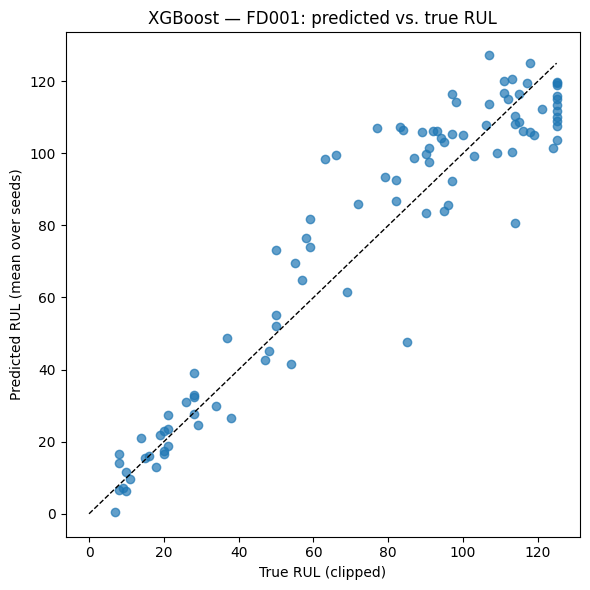

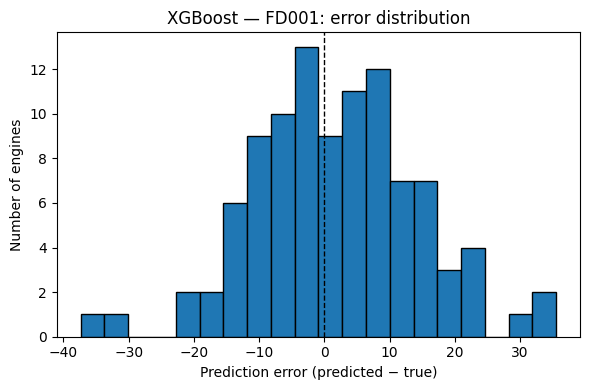

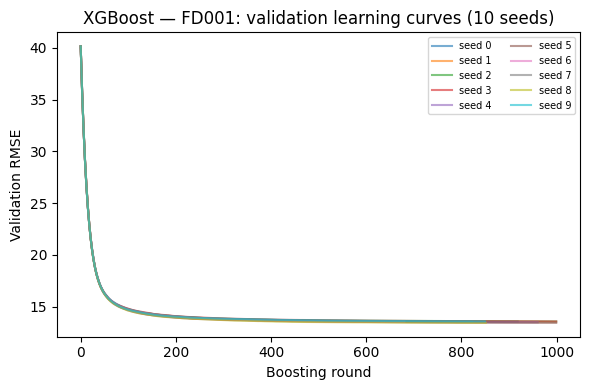

Figures saved to: /content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003/results/XGB_FD001/figures


In [18]:
# S18 — Figures
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(predictions_df["y_true_clipped"], predictions_df["y_pred_mean"], alpha=0.7)
lims = [0, CONFIG["rul_clip"]]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("True RUL (clipped)")
ax.set_ylabel("Predicted RUL (mean over seeds)")
ax.set_title(f"XGBoost — {DATASET_ID}: predicted vs. true RUL")
fig.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, "pred_vs_true.png"), dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
errors = predictions_df["y_pred_mean"] - predictions_df["y_true_clipped"]
ax.hist(errors, bins=20, edgecolor="black")
ax.axvline(0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("Prediction error (predicted − true)")
ax.set_ylabel("Number of engines")
ax.set_title(f"XGBoost — {DATASET_ID}: error distribution")
fig.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, "error_distribution.png"), dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for log in seed_logs:
    ax.plot(log["val_rmse_history"], alpha=0.6, label=f"seed {log['seed']}")
ax.set_xlabel("Boosting round")
ax.set_ylabel("Validation RMSE")
ax.set_title(f"XGBoost — {DATASET_ID}: validation learning curves (10 seeds)")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, "learning_curves.png"), dpi=300)
plt.show()

print("Figures saved to:", FIGS_DIR)
